# LET'S EXPLORE THE Market  
# My Self :- Roshan Marathe 
## GR_ID = 10258
### Role :- Data Analyst  
# Date = 24/01/2026
# Today I Present Here indian_reatails Analyis (Tech War)

# IMPORT LIBARIES 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd 
sns.set_theme(style="whitegrid", context="talk")

In [3]:
df=pd.read_csv("indian_reatail.csv")

In [4]:
df.head()

,Order_ID,Order_Date,Region,City,Customer_Type,Product_Category,Quantity,Unit_Price,Discount_Percent,Revenue
0,200000,2021-06-25,East,Ahmedabad,New,Clothing,1.0,1371.52,5.0,1302.9440
1,200001,2021-07-16,East,Kolkata,Returning,Food,6.0,3343.51,0.0,20061.0600
2,200002,2022-06-22,Central,Pune,New,NaN,4.0,24849.97,10.0,89459.8920
3,200003,2022-05-18,South,Pune,New,Furniture,7.0,30297.19,15.0,180268.2805
4,200004,2022-08-03,Central,Delhi,Returning,Accessories,8.0,8876.00,15.0,60356.8000


# DATA SHAPE (DISPLAY)

In [5]:
df.shape

(52000, 10)

# COLUMNS 

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'Region', 'City', 'Customer_Type',
       'Product_Category', 'Quantity', 'Unit_Price', 'Discount_Percent',
       'Revenue'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          52000 non-null  int64  
 1   Order_Date        52000 non-null  object 
 2   Region            46722 non-null  object 
 3   City              50441 non-null  object 
 4   Customer_Type     46747 non-null  object 
 5   Product_Category  46815 non-null  object 
 6   Quantity          42209 non-null  float64
 7   Unit_Price        51753 non-null  float64
 8   Discount_Percent  46748 non-null  float64
 9   Revenue           42004 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 4.0+ MB


# FIRST AND LAST ROW (5)

In [8]:
df.head(5)

,Order_ID,Order_Date,Region,City,Customer_Type,Product_Category,Quantity,Unit_Price,Discount_Percent,Revenue
0,200000,2021-06-25,East,Ahmedabad,New,Clothing,1.0,1371.52,5.0,1302.9440
1,200001,2021-07-16,East,Kolkata,Returning,Food,6.0,3343.51,0.0,20061.0600
2,200002,2022-06-22,Central,Pune,New,NaN,4.0,24849.97,10.0,89459.8920
3,200003,2022-05-18,South,Pune,New,Furniture,7.0,30297.19,15.0,180268.2805
4,200004,2022-08-03,Central,Delhi,Returning,Accessories,8.0,8876.00,15.0,60356.8000


In [9]:
df.tail(5)

,Order_ID,Order_Date,Region,City,Customer_Type,Product_Category,Quantity,Unit_Price,Discount_Percent,Revenue
51995,233582,2021-11-17,South,Bengaluru,New,NaN,3.0,49025.97,20.0,117662.3280
51996,231702,2021-07-20,North,Hyderabad,NaN,Accessories,4.0,17695.26,25.0,53085.7800
51997,238237,2021-06-25,NaN,Delhi,New,Electronics,3.0,22730.41,15.0,57962.5455
51998,222358,2022-10-22,North,Kolkata,New,Furniture,3.0,40229.84,5.0,114655.0440
51999,248246,2021-04-20,North,Bengaluru,New,Electronics,2.0,31329.17,NaN,62658.3400


# Task 2 = Data Cleaning And EDA

## Cheack and handle missing data

In [14]:
print("Missing values BEFORE cleaning:\n")
print(df.isna().sum())
print("\n-----------------------------\n")


Missing values BEFORE cleaning:

Order_ID               0
Order_Date             0
Region                 0
City                   0
Customer_Type          0
Product_Category       0
Quantity            9791
Unit_Price             0
Discount_Percent    5252
Revenue             9996
dtype: int64

-----------------------------




# -----------------------------
# 3️ = Handle Categorical Columns (Missing Value)
# -----------------------------

Missing values AFTER cleaning:

Order_ID            0
Order_Date          0
Region              0
City                0
Customer_Type       0
Product_Category    0
Quantity            0
Unit_Price          0
Discount_Percent    0
Revenue             0
dtype: int64

Dataset Info After Cleaning:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          52000 non-null  int64  
 1   Order_Date        52000 non-null  object 
 2   Region            52000 non-null  object 
 3   City              52000 non-null  object 
 4   Customer_Type     52000 non-null  object 
 5   Product_Category  52000 non-null  object 
 6   Quantity          52000 non-null  float64
 7   Unit_Price        52000 non-null  float64
 8   Discount_Percent  52000 non-null  float64
 9   Revenue           52000 non-null  float64
dtypes: float64(4), int64(1), o

# -----------------------------
# 4️ Handle Numerical Columns
# -----------------------------

In [17]:
# Unit Price → Median 

df["Unit_Price"] = df["Unit_Price"].fillna(df["Unit_Price"].median())

df["Discount_Percent"] = df["Discount_Percent"].fillna(0)

# Quantity → Category-wise Median 
df["Quantity"] = (
    df.groupby("Product_Category")["Quantity"]
      .transform(lambda x: x.fillna(x.median()))
)


# -----------------------------
#  Revenue → Recalculate 
# -----------------------------

In [40]:
df["Revenue"] = (
    df["Quantity"]* df["Unit_Price"] * (1 - df["Discount_Percent"] / 100)
)

# -----------------------------
#  Final Validation
# -----------------------------

In [41]:

print("Missing values AFTER cleaning:\n")
print(df.isna().sum())


Missing values AFTER cleaning:

Order_ID            0
Order_Date          0
Region              0
City                0
Customer_Type       0
Product_Category    0
Quantity            0
Unit_Price          0
Discount_Percent    0
Revenue             0
dtype: int64


# -----------------------------
#  Dataset Info 
# -----------------------------

In [ ]:

print("\nDataset Info After Cleaning:\n")
print(df.info())


# -----------------------------
#  Detect duplicate
# -----------------------------

In [ ]:
df.duplicated ().sum()

# -----------------------------
#  Drop Duplicate
# -----------------------------

In [26]:
df.drop_duplicates(inplace=True)

# Re-chake Duplicate (Will Remove)

In [27]:
df.duplicated ().sum()

np.int64(0)

# Summary Statistics ( Numeric and CATEGORICAL)

In [29]:
# -----------------------------
# 1️ NUMERICAL SUMMARY STATISTICS
# -----------------------------
print("===== NUMERICAL SUMMARY STATISTICS =====\n")

numeric_summary = df.describe().T
numeric_summary["median"] = df.median(numeric_only=True)
numeric_summary["missing_values"] = df.isna().sum()

print(numeric_summary)

===== NUMERICAL SUMMARY STATISTICS =====

                    count           mean           std          min  \
Order_ID          50000.0  224999.500000  14433.901067  200000.0000   
Quantity          50000.0       4.990180      2.322126       1.0000   
Unit_Price        50000.0   24576.550680  14982.869397     190.1300   
Discount_Percent  50000.0      11.228900      8.916440       0.0000   
Revenue           50000.0  108705.737675  90035.723711     142.5975   

                         25%        50%         75%        max     median  \
Order_ID          212499.750  224999.50  237499.250  249999.00  224999.50   
Quantity               3.000       5.00       7.000       9.00       5.00   
Unit_Price         11261.430   25364.68   38055.920   49424.72   25364.68   
Discount_Percent       0.000      10.00      20.000      25.00      10.00   
Revenue            34722.045   85260.75  165102.705  444822.48   85260.75   

                  missing_values  
Order_ID                       0 

In [30]:

# -----------------------------
# CATEGORICAL SUMMARY STATISTICS
# -----------------------------
print("===== CATEGORICAL SUMMARY STATISTICS =====\n")

categorical_cols = df.select_dtypes(include="object").columns

cat_summary = pd.DataFrame({
    "Unique_Values": df[categorical_cols].nunique(),
    "Most_Frequent": df[categorical_cols].mode().iloc[0],
    "Frequency": df[categorical_cols].apply(lambda x: x.value_counts().iloc[0])
})

print(cat_summary)
print("\n----------------------------------------\n")

===== CATEGORICAL SUMMARY STATISTICS =====

                  Unique_Values Most_Frequent  Frequency
Order_Date                 1000    2021-03-17         72
Region                        6          East       9062
City                          9         Delhi       6565
Customer_Type                 3     Returning      22511
Product_Category              6   Accessories       9054

----------------------------------------



# Category Distrubution (only 1 )

In [38]:
print("===== CATEGORICAL Distribution =====\n")
df["Product_Category"].value_counts()

===== CATEGORICAL Distribution =====



Product_Category
Accessories    9054
Food           9025
Electronics    9020
Furniture      8997
Clothing       8916
Unknown        4988
Name: count, dtype: int64

# Task 3 * Bussines Data Analysis with Data VIsuliZation

# Bar Chart

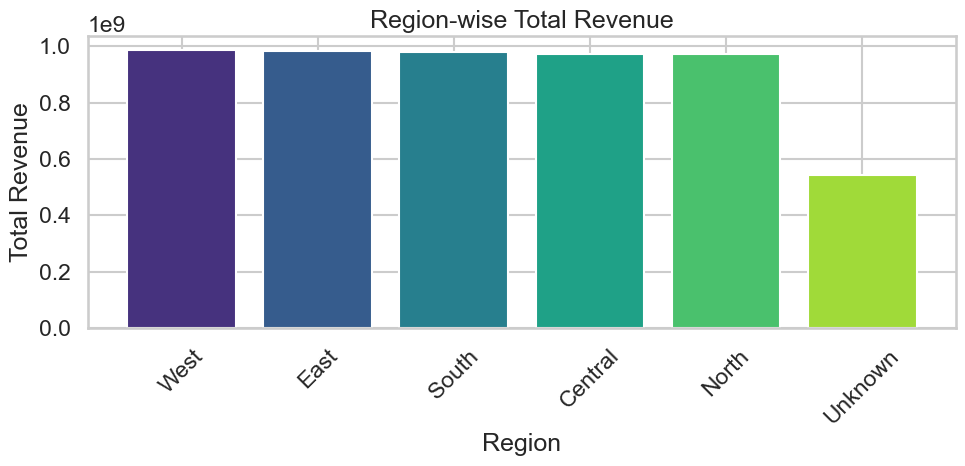

In [61]:

region_revenue = (
    df.groupby("Region")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))
bars = plt.bar(
   region_revenue.index,
    region_revenue.values,
    color=sns.color_palette("viridis", len(region_revenue)))

plt.title("Region-wise Total Revenue")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Line Chart

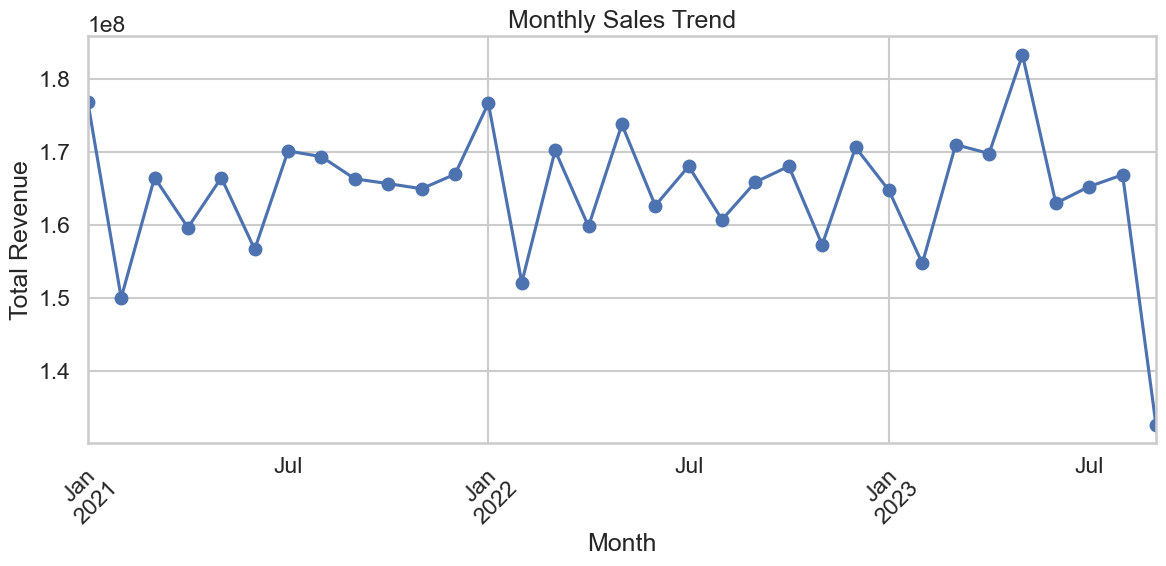

In [70]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Revenue"]
    .sum()
)

plt.figure(figsize=(12,6))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Pie Chart

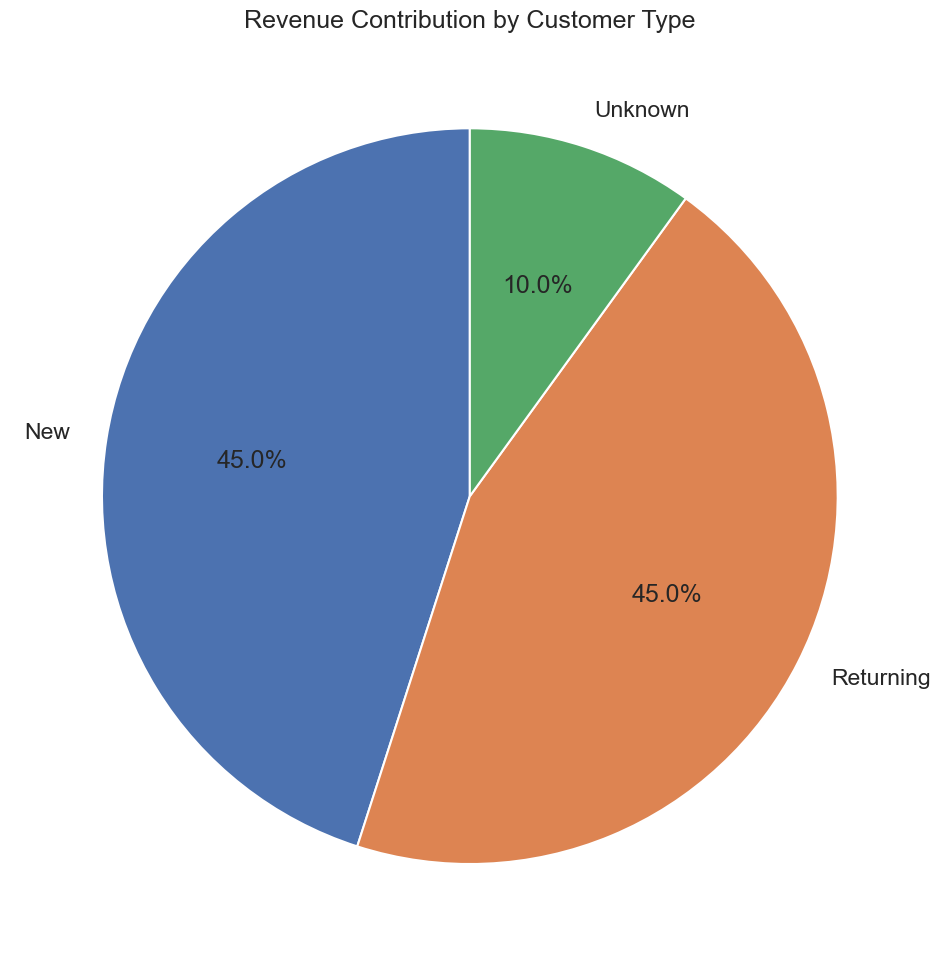

In [105]:
customer_revenue = (
    df.groupby("Customer_Type")["Revenue"]
    .sum()
)

plt.figure(figsize=(10,10))
customer_revenue.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Revenue Contribution by Customer Type")
plt.ylabel("")
plt.tight_layout()
plt.show()


# Scatter Chart

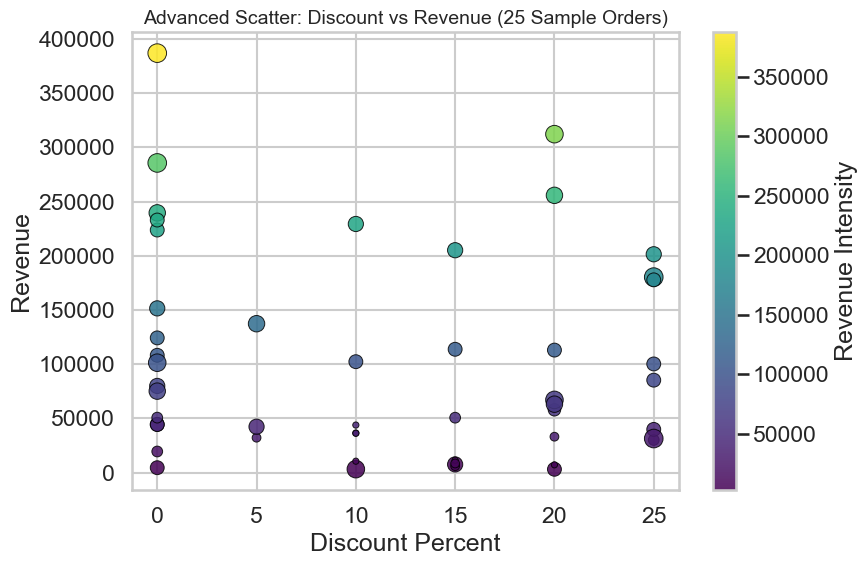

In [99]:
# -----------------------------
# Sample only 50 rows (clarity)
# -----------------------------
sample_df = df.sample(n=50, random_state=42)
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    sample_df["Discount_Percent"],
    sample_df["Revenue"],
    s=sample_df["Quantity"] * 20,      
    c=sample_df["Revenue"],             
    cmap="viridis",                     
    alpha=0.85,
    edgecolors="black",
    linewidth=0.7
)
cbar = plt.colorbar(scatter)
cbar.set_label("Revenue Intensity")
plt.title("Advanced Scatter: Discount vs Revenue (25 Sample Orders)", fontsize=14)
plt.xlabel("Discount Percent")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


# Subplots

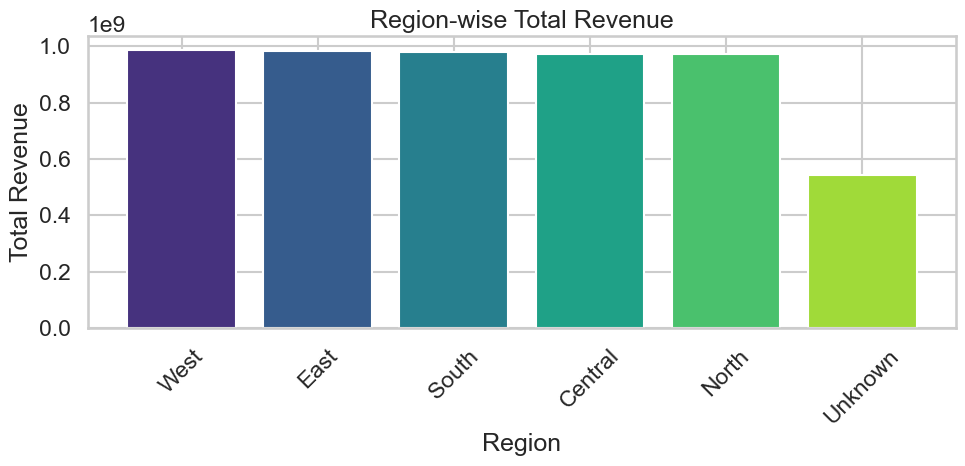

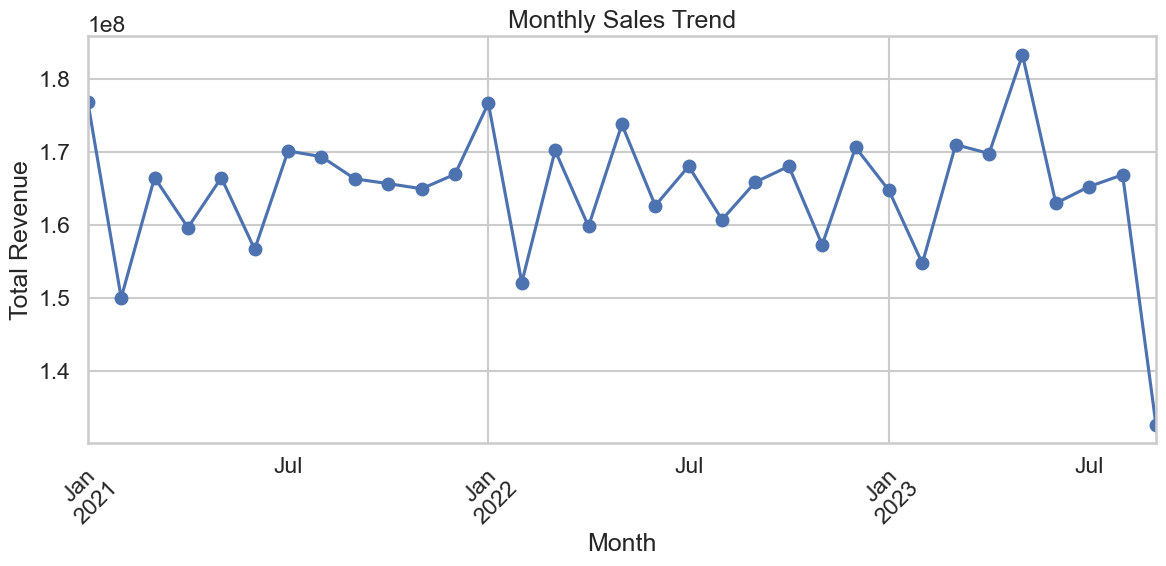

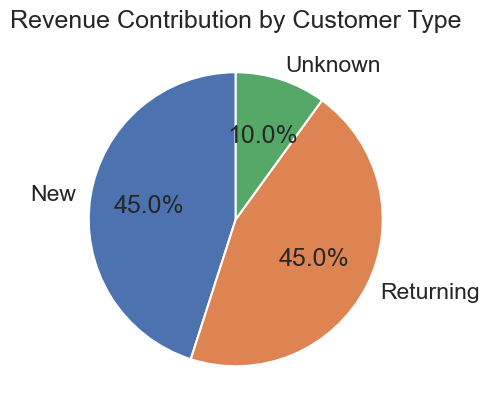

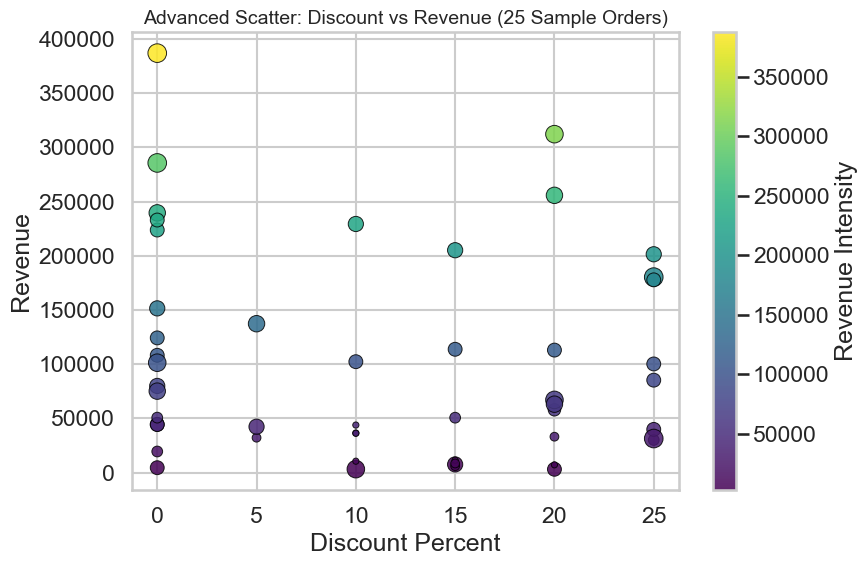

<Figure size 640x480 with 0 Axes>

In [110]:

# fig, axes = plt.subplots(3, 3, figsize=(14,10))
# fig.suptitle("Business Data Analysis Dashboard", fontsize=18, fontweight="bold")

# -----------------------------
# 1 Region-wise Revenue (Bar)
# -----------------------------
region_revenue = (
    df.groupby("Region")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))
bars = plt.bar(
   region_revenue.index,
    region_revenue.values,
    color=sns.color_palette("viridis", len(region_revenue)))

plt.title("Region-wise Total Revenue")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 2 Line Chart
# -----------------------------
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Revenue"]
    .sum()
)

plt.figure(figsize=(12,6))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# -----------------------------
#  (Pie)
# -----------------------------
customer_revenue = (
    df.groupby("Customer_Type")["Revenue"]
    .sum()
)

plt.figure(figsize=(5,6))
customer_revenue.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Revenue Contribution by Customer Type")
plt.ylabel("")
plt.tight_layout()
plt.show()


# -----------------------------
# 4️⃣ Advanced Scatter 
# -----------------------------
sample_df = df.sample(n=50, random_state=42)
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    sample_df["Discount_Percent"],
    sample_df["Revenue"],
    s=sample_df["Quantity"] * 20,      
    c=sample_df["Revenue"],             
    cmap="viridis",                     
    alpha=0.85,
    edgecolors="black",
    linewidth=0.7
)
cbar = plt.colorbar(scatter)
cbar.set_label("Revenue Intensity")
plt.title("Advanced Scatter: Discount vs Revenue (25 Sample Orders)", fontsize=14)
plt.xlabel("Discount Percent")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Data Quality & Missing Values


## The dataset initially contained significant missing values across both categorical and numerical variables.

## Categorical attributes such as Region, Customer_Type, and Product_Category had a high proportion of missing entries, 

## Numerical variables like Quantity and Revenue showed substantial missingness, 

#  Action Taken:
# Missing values were handled using Fill NA (Mode,Median,mode), 


# Customer & Sales Patterns

## Customer behavior appears like they think diffrent from other , with both frequent low-value purchases and infrequent high-value purchases..

#  Final Overview

## After The Cleaning Datasate There have no any duplicate and missing value


# “The analysis reveals concentrated regional and category-level revenue, strong dependence on returning customers, seasonal demand patterns, and a non-linear discount–revenue relationship,decisions in marketing, pricing, and inventory management.”

# ========================= Thank You ++++++++++++++++++++++++++++++++++